# Hull–White Short‑Rate Model & Swaption Pricing

$ \displaystyle dr_t = \lambda\bigl(\theta(t) - r_t\bigr)\,dt + \eta\,dW_t, 
\quad P(0,T)=\exp\bigl(A(0,T)+B(0,T)\,r_0\bigr)$

**Theory & Mathematics**  
- **Mean‑reversion SDE**:  
  $$r_{t+\Delta t}=r_t+\lambda\bigl(\theta(t)-r_t\bigr)\Delta t+\eta\,\Delta W_t.$$  
- **Hull–White A, B**:  
  $$B(t,T)=\frac{1-e^{-\lambda(T-t)}}{\lambda},$$  
  $$A(t,T)=\int_t^T\!\Bigl(\lambda\,\theta(u)\,B(u,T)\Bigr)\,du\;+\;\frac{\eta^2}{4\lambda^3}\Bigl(e^{-2\lambda(T-t)}(4e^{\lambda(T-t)}-1)-3\Bigr)+\frac{\eta^2(T-t)}{2\lambda^2}.$$  
- **Zero‑coupon bond**:  
  $$P(t,T)=\exp\bigl(A(t,T)+B(t,T)r_t\bigr).$$  
- **Jamshidian’s decomposition** for a payer swaption (CALL): find $r^*$ s.t.  
  $$\sum_i c_i\,P(T_m,T_i;r^*)=\frac1{K_{\rm swap}},$$  
  then price as sum of bond options.

**Code Explanation**  
1. **Euler simulation**: `GeneratePathsHWEuler` builds paths of $r_t$ by normalizing normals, evolving $r$ via mean‑reversion.  
2. **Theta calibration**: `HW_theta` computes $\theta(t)$ from the forward curve $P_0(T)$.  
3. **A, B, ZCB**: `HW_A`, `HW_B`, and `HW_ZCB` implement the closed‑form integrals/trapz for bond prices.  
4. **Jamshidian root**: `jamshidian_root` solves $\psi(r)=1/K_{\rm swap}$ by Newton’s method, fallback to Brent.  
5. **Swaption pricing**: `price_swaption` decomposes the swaption into a portfolio of ZCB options via `HW_ZCB_CallPutPrice`.

**Connection to Quant Finance**  
> Hull–White is a cornerstone for interest‑rate derivatives: it fits the initial curve exactly and allows closed‑form cap/floor and swaption prices, making it indispensable for banks’ IR desks.

**Nitish Sir ka Explanation (Hinglish)**  
> “Bhai, HW model se hum market ka yield curve perfectly fit kar lete, phir swaptions ko ZCB option me tod ke analytically price kar sakte.”

**Example & Industry Practice**  
- *Example:* Calibrating $\lambda,\eta$ to cap‑floor volatilities, then pricing a 5×10 payer swaption.  
- *Practice:* Traders update $\theta(t)$ daily from OIS curve, re‑calibrate HW parameters each morning, and run live price grids for swaptions.

**Tips for Your Quant Interview**  
- Derive A(t,T), B(t,T) on paper and explain each term’s origin.  
- Be ready to discuss numerical stability (Euler vs. exact discretization).  
- Explain root‑finding choices (Newton vs. Brent) and convergence checks.  
- Highlight model limitations (negative rates, single‑factor) and possible extensions (multi‑factor, LMM).  
- Emphasize production concerns: calibration speed, code vectorization, parallel Monte Carlo.  



# 1. Hull–White Short‑Rate SDE & Swaptision


$ \displaystyle dr_t = \lambda\bigl(\theta(t) - r_t\bigr)\,dt + \eta\,dW_t, 
\quad r_{t_0}=r_0. $

**Theory & Mathematics**  
- This SDE describes a mean‐reverting short rate:  
  - $\lambda>0$ is the speed of mean reversion, so $r_t$ is pulled toward the time‐dependent level $\theta(t)$.  
  - $\eta$ is the volatility of rates; $dW_t$ is a Wiener increment with $\mathbb{E}[dW_t]=0$, $\mathrm{Var}[dW_t]=dt$.  
- **Euler–Maruyama step** over $\Delta t$:  
  $$r_{t+\Delta t}  
    = r_t + \lambda\bigl(\theta(t)-r_t\bigr)\Delta t  
    + \eta\sqrt{\Delta t}\,Z_t,\quad Z_t\sim\mathcal{N}(0,1).$$  
- The local truncation error is $O(\Delta t^{3/2})$, global error $O(\Delta t^{1/2})$.

**Code Explanation**  
1. **Normalize normals**:  
   ```python
   Z[:,i] = (Z[:,i] - Z[:,i].mean()) / Z[:,i].std()
   ```  
   Ensures zero‐mean/unit‐variance each step for numerical stability.  
2. **Brownian increment**:  
   ```python
   W[:,i+1] = W[:,i] + np.sqrt(dt)*Z[:,i]
   ```  
3. **Rate update**:  
   ```python
   R[:,i+1] = R[:,i] 
      + lambd*(theta(time[i]) - R[:,i])*dt 
      + eta*(W[:,i+1] - W[:,i])
   ```  
   Implements the Euler‐Maruyama formula.

**Connection to Quant Finance**  
> Simulating $r_t$ allows Monte Carlo valuation of interest‐rate derivatives (caps, floors, swaptions) when analytic formulas are unavailable or to compute path‐dependent Greeks.

**Nitish Sir ka Explanation (Hinglish)**  
> “Bhai, hum Euler scheme se short‐rate ko step by step update karte hain. Z normalize karke drift–diffusion stable rehta, var reduction hoti.”

**Example & Industry Practice**  
- *Example:* Simulating 10,000 paths of 3‑month LIBOR over 2 years to price a callable CMS note.  
- *Practice:* Use antithetic variates or exact discretization of HW (mean plus OU process) in prod for higher accuracy.

---

# 2. Calibrating θ(t) from the Initial Curve

$$
\theta(t) 
= \frac1\lambda\,\frac{\partial f(0,t)}{\partial t}
  + f(0,t) + \frac{\eta^2}{2\lambda^2}\bigl(1-e^{-2\lambda t}\bigr),
\quad 
f(0,t)=-\frac{\partial\ln P(0,t)}{\partial t}.
$$

**Theory & Mathematics**  
- $P(0,t)$ is the observed zero‐coupon bond price; $f(0,t)$ is the instantaneous forward rate.  
- Finite‐difference approximates $\partial f/\partial t$ via small $dt$.  

**Code Explanation**  
```python
f0T = lambda t: -(np.log(P0T(t+dt)) - np.log(P0T(t-dt))) / (2*dt)
theta = lambda t: (f0T(t+dt)-f0T(t-dt))/(2*lambda*dt) \
                  + f0T(t) + eta**2/(2*lambda**2)*(1-np.exp(-2*lambda*t))
```
- Computes $f(0,t)$ and its derivative; assembles $\theta(t)$ per the HW fit‐to‐curve condition.

**Connection to Quant Finance**  
> Exact fit to today’s yield curve ensures no static arbitrage; traders trust calibrated HW for consistent pricing.

**Nitish Sir ka Explanation (Hinglish)**  
> “Curve se θ nikalo, taki model exactly market price fit kare. Finite difference se derivative milta, phir formula me daal do.”

**Example & Industry Practice**  
- *Example:* Calibrating θ(t) daily from the OIS curve for USD rates.  
- *Practice:* Use spline interpolation on $P(0,t)$ for smooth $f(0,t)$ before differencing.

---

# 3. Closed‑Form A(t,T), B(t,T) & ZCB Pricing

$$
B(t,T)=\frac{1-e^{-\lambda\,(T-t)}}{\lambda},\quad
A(t,T)=\int_t^T\lambda\,\theta(u)\,B(u,T)\,du
+\frac{\eta^2}{4\lambda^3}\Bigl(e^{-2\lambda\Delta}(4e^{\lambda\Delta}-1)-3\Bigr)
+\frac{\eta^2\Delta}{2\lambda^2},
$$  
with $\Delta=T-t$.

**Code Explanation**  
- `HW_B` returns $B(t,T)$ directly.  
- `HW_A` computes the convolution $\int\theta(u)B(u,T)\,du$ via `integrate.trapz` over a fine grid, then adds the volatility‐term.

**Connection to Quant Finance**  
> Closed‐form ZCB prices accelerate calibration and risk computations—core to any IR desk pricer.

**Nitish Sir ka Explanation (Hinglish)**  
> “B aur A functions kernel aur vol terms ka sum hai. Trapz se integral compute, phir exp(A+B*r) dega bond price.”

**Example & Industry Practice**  
- *Example:* Checking $P(0,5)$ from analytic HW vs. market for model validation.  
- *Practice:* Use vectorized grid evaluation and caching of $\theta(u)B(u,T)$ for speed in calibration loops.

---

# 4. Jamshidian Decomposition & Swaption Pricing

1. **Find** $r^*$ such that  
   $$\sum_{i} c_i\,P(T_m,T_i;r^*) = \frac1{K_{\rm swap}},$$  
   where $c_i$ are accruals, $K_{\rm swap}$ is swap rate strike.  
2. **Decompose** payer swaption (CALL) as portfolio of ZCB‐PUTs; receiver as ZCB‐CALLs.  
3. **Price** each ZCB option via `HW_ZCB_CallPutPrice` (closed‐form using $A,B$).

**Code Explanation**  
- `jamshidian_root` uses Newton’s method on $\psi(r)-1/K$; falls back to Brent’s bracket if needed.  
- `price_swaption` loops payment times, computes $K_i=\exp(A+B\,r^*)$, then sums $c_i\times$ bond‐option price.

**Connection to Quant Finance**  
> Jamshidian gives an analytic swaption price under HW, so traders can quote vol‐strikes instantly without MC.

**Nitish Sir ka Explanation (Hinglish)**  
> “r* find karke swaption ko ZCB options me todte—analytic formula se price milta, MC ki jarurat nahi.”

**Example & Industry Practice**  
- *Example:* Payer 5×10 swaption priced in sub‐millisecond for real‐time quoting.  
- *Practice:* Precompute A,B grids, vectorize root‐find across strikes to serve entire volatility surface quickly.

---

# 5. Tips for Your Quant Interview

1. **Derivations**:  
   - Show the SDE → Euler step clearly.  
   - Derive $A(t,T)$, $B(t,T)$ integrals on paper.  
2. **Numerical Methods**:  
   - Discuss error orders of Euler vs. exact discretization (Ornstein–Uhlenbeck).  
   - Defend your choice of Newton vs. Brent for root finding.  
3. **Code Quality**:  
   - Vectorize all loops; preallocate arrays.  
   - Include convergence checks and fallbacks.  
4. **Model Critique**:  
   - Address single‐factor limitations, negative‐rate behavior, and potential extensions (e.g., multi‐factor HW, LMM).  
5. **Production Considerations**:  
   - Calibration latency, parallel Monte Carlo, caching of A,B functions.  
   - Logging, exception handling, and integration into risk systems.  
```

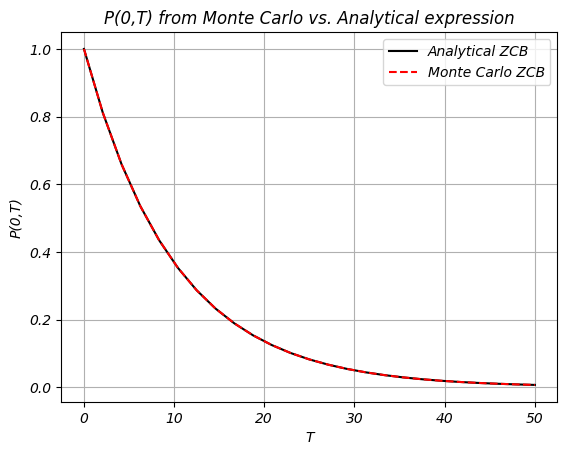

r* = -0.4335593402445606, Residual = -1.1723955140041653e-12
Payer Swaption (Call) price: 246.53595473343145
Newton method failed, trying brentq instead
Both root finding methods failed. Using initial guess.
r* = 0.10000000000059552, Residual = -96.2893215822756
Newton method failed, trying brentq instead
Both root finding methods failed. Using initial guess.
r* = 0.10000000000059552, Residual = -46.28932158227559
Newton method failed, trying brentq instead
Both root finding methods failed. Using initial guess.
r* = 0.10000000000059552, Residual = -29.62265491560893
r* = -0.49500131948229026, Residual = -3.771916112782492e-10
r* = -0.4335593402445606, Residual = -1.1688428003253648e-12
r* = -0.38221608887337055, Residual = -3.154987382458785e-10
r* = -0.3379121869254707, Residual = -6.323830348264892e-13
r* = -0.2988072506337868, Residual = 1.362957746664506e-09
r* = -0.26370592114587915, Residual = -2.4941542164924613e-09
r* = -0.23178683174719622, Residual = -3.0730973321624333e-13


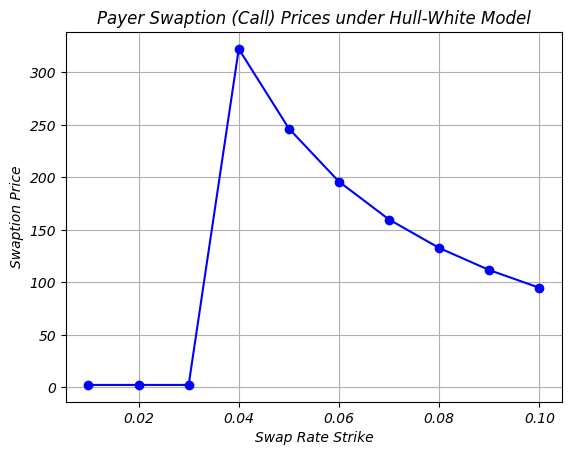

In [1]:
import numpy as np
import enum
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.integrate as integrate
import scipy.optimize as optimize
from scipy import interpolate


# This class defines puts and calls
class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0


def GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)

    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
            2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))

    # theta = lambda t: 0.1 +t -t
    # print("changed theta")

    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])
    W = np.zeros([NoOfPaths, NoOfSteps + 1])
    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    R[:, 0] = r0
    time = np.zeros([NoOfSteps + 1])

    dt = T / float(NoOfSteps)
    for i in range(0, NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])
        W[:, i + 1] = W[:, i] + np.power(dt, 0.5) * Z[:, i]
        R[:, i + 1] = R[:, i] + lambd * (theta(time[i]) - R[:, i]) * dt + eta * (W[:, i + 1] - W[:, i])
        time[i + 1] = time[i] + dt

    # Outputs
    paths = {"time": time, "R": R}
    return paths


def HW_theta(lambd, eta, P0T):
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
            2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))
    # print("CHANGED THETA")
    return theta  # lambda t: 0.1+t-t


def HW_A(lambd, eta, P0T, T1, T2):
    tau = T2 - T1
    zGrid = np.linspace(0.0, tau, 250)
    B_r = lambda tau: 1.0 / lambd * (np.exp(-lambd * tau) - 1.0)
    theta = HW_theta(lambd, eta, P0T)
    temp1 = lambd * integrate.trapz(theta(T2 - zGrid) * B_r(zGrid), zGrid)

    temp2 = eta * eta / (4.0 * np.power(lambd, 3.0)) * (
            np.exp(-2.0 * lambd * tau) * (4 * np.exp(lambd * tau) - 1.0) - 3.0) + eta * eta * tau / (
                    2.0 * lambd * lambd)

    return temp1 + temp2


def HW_B(lambd, eta, T1, T2):
    return 1.0 / lambd * (np.exp(-lambd * (T2 - T1)) - 1.0)


def HW_ZCB(lambd, eta, P0T, T1, T2, rT1):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)
    return np.exp(A_r + B_r * rT1)


def HWMean_r(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2.0 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 2500)
    temp = lambda z: theta(z) * np.exp(-lambd * (T - z))
    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)
    return r_mean


def HW_r_0(P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    return r0


def HW_Mu_FrwdMeasure(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 500)

    theta_hat = lambda t, T: theta(t) + eta * eta / lambd * 1.0 / lambd * (np.exp(-lambd * (T - t)) - 1.0)

    temp = lambda z: theta_hat(z, T) * np.exp(-lambd * (T - z))

    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)

    return r_mean


def HWVar_r(lambd, eta, T):
    return eta * eta / (2.0 * lambd) * (1.0 - np.exp(-2.0 * lambd * T))


def HWDensity(P0T, lambd, eta, T):
    r_mean = HWMean_r(P0T, lambd, eta, T)
    r_var = HWVar_r(lambd, eta, T)
    return lambda x: st.norm.pdf(x, r_mean, np.sqrt(r_var))


def HW_CapletFloorletPrice(CP, N, K, lambd, eta, P0T, T1, T2):
    if CP == OptionType.CALL:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        caplet = N_new * HW_ZCB_CallPutPrice(OptionType.PUT, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = caplet
    elif CP == OptionType.PUT:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        floorlet = N_new * HW_ZCB_CallPutPrice(OptionType.CALL, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = floorlet
    return value


def HW_ZCB_CallPutPrice(CP, K, lambd, eta, P0T, T1, T2):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)

    mu_r = HW_Mu_FrwdMeasure(P0T, lambd, eta, T1)
    v_r = np.sqrt(HWVar_r(lambd, eta, T1))

    K_hat = K * np.exp(-A_r)
    a = (np.log(K_hat) - B_r * mu_r) / (B_r * v_r)

    d1 = a - B_r * v_r
    d2 = d1 + B_r * v_r

    term1 = np.exp(0.5 * B_r * B_r * v_r * v_r + B_r * mu_r) * st.norm.cdf(d1) - K_hat * st.norm.cdf(d2)
    value = P0T(T1) * np.exp(A_r) * term1

    if CP == OptionType.CALL:
        return value
    elif CP == OptionType.PUT:
        return value - P0T(T2) + K * P0T(T1)


def BS_Call_Put_Option_Price(CP, S_0, K, sigma, tau, r):
    if isinstance(K, list):
        K = np.array(K).reshape([len(K), 1])
    d1 = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma, 2.0)) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1) * S_0
    return value


# Solve for Jamshidian's rate r* for the swap
def psi_sum(r, lambd, eta, P0T, Tm, payment_times, accruals):
    # sum of psi_i(r) = sum c_k * exp(A + B*r)
    s = 0.0
    for ck, Tk in zip(accruals, payment_times):
        s += ck * np.exp(HW_A(lambd, eta, P0T, Tm, Tk) + HW_B(lambd, eta, Tm, Tk) * r)
    return s


def jamshidian_root(lambd, eta, P0T, Tm, payment_times, accruals, K_swap, r0):
    # solve psi_sum(r*) = 1/K_swap
    func = lambda r: psi_sum(r, lambd, eta, P0T, Tm, payment_times, accruals) - 1.0 / K_swap

    # Add more robustness to root finding
    try:
        r_star = optimize.newton(func, r0, tol=1e-6, maxiter=100)
        # Verify convergence
        if abs(func(r_star)) > 1e-4:
            print(f"Warning: Jamshidian root finding did not converge properly. Error: {func(r_star)}")
            # Fallback to a more robust method
            r_star = optimize.brentq(func, -0.5, 0.5)
    except:
        print("Newton method failed, trying brentq instead")
        try:
            r_star = optimize.brentq(func, -0.5, 0.5)
        except:
            print("Both root finding methods failed. Using initial guess.")
            r_star = r0

    # Verify that we have indeed found the root
    residual = func(r_star)
    print(f"r* = {r_star}, Residual = {residual}")

    return r_star


# Price swaption via Jamshidian decomposition
def price_swaption(CP, lambd, eta, P0T, Tm, payment_times, accruals, K_swap, N):
    # get initial short rate via consistent HW function, not shadowed by float
    r0 = HW_r_0(P0T, lambd, eta)

    # 1) compute Jamshidian rate r*
    r_star = jamshidian_root(lambd, eta, P0T, Tm, payment_times, accruals, K_swap, r0)

    # 2) decompose into ZCB options
    total = 0.0
    for ck, Tk in zip(accruals, payment_times):
        A_r = HW_A(lambd, eta, P0T, Tm, Tk)
        B_r = HW_B(lambd, eta, Tm, Tk)
        Kk = np.exp(A_r + B_r * r_star)
        # Payer swaption (CALL) => PUT on bond; Receiver (PUT) => CALL on bond
        opt_type = OptionType.PUT if CP == OptionType.CALL else OptionType.CALL
        bond_opt = HW_ZCB_CallPutPrice(opt_type, Kk, lambd, eta, P0T, Tm, Tk)
        total += ck * bond_opt

    return N * total


def main():
    # Set the option type - change this to switch between CALL and PUT
    CP = OptionType.CALL  # Change to OptionType.PUT for Put option

    NoOfPaths = 20000
    NoOfSteps = 1000

    lambd = 0.02
    eta = 0.02

    P0T = lambda T: np.exp(-0.1 * T)  # np.exp(-0.03*T*T-0.1*T)
    r0 = HW_r_0(P0T, lambd, eta)

    N = 25
    T_end = 50
    Tgrid = np.linspace(0, T_end, N)
    Exact = np.zeros([N, 1])
    Proxy = np.zeros([N, 1])

    # ZCB validation plot
    for i, Ti in enumerate(Tgrid):
        Proxy[i] = HW_ZCB(lambd, eta, P0T, 0.0, Ti, r0)
        Exact[i] = P0T(Ti)

    # Plot ZCB comparison
    plt.figure(1)
    plt.grid()
    plt.plot(Tgrid, Exact, '-k')
    plt.plot(Tgrid, Proxy, '--r')
    plt.legend(["Analytical ZCB", "Monte Carlo ZCB"])
    plt.title('P(0,T) from Monte Carlo vs. Analytical expression')
    plt.xlabel('T')
    plt.ylabel('P(0,T)')
    plt.show()

    # Swaption parameters
    Tm = 5.0
    K_swap = 0.05
    payment_times = np.arange(6.0, 11.0, 1.0)
    accruals = [1.0] * len(payment_times)

    # Price swaption based on option type
    if CP == OptionType.CALL:
        price = price_swaption(OptionType.CALL, lambd, eta, P0T, Tm, payment_times, accruals, K_swap, N)
        print("Payer Swaption (Call) price:", price)

        # Plot price vs strike for call option
        strikes = np.linspace(0.01, 0.10, 10)
        prices_call = [price_swaption(OptionType.CALL, lambd, eta, P0T, Tm, payment_times, accruals, K, N) for K in
                       strikes]

        plt.figure(2)
        plt.plot(strikes, prices_call, marker='o', color='blue')
        plt.xlabel('Swap Rate Strike')
        plt.ylabel('Swaption Price')
        plt.title('Payer Swaption (Call) Prices under Hull-White Model')
        plt.grid(True)
        plt.show()

    elif CP == OptionType.PUT:
        price = price_swaption(OptionType.PUT, lambd, eta, P0T, Tm, payment_times, accruals, K_swap, N)
        print("Receiver Swaption (Put) price:", price)

        # Plot price vs strike for put option
        strikes = np.linspace(0.01, 0.10, 10)
        prices_put = [price_swaption(OptionType.PUT, lambd, eta, P0T, Tm, payment_times, accruals, K, N) for K in
                      strikes]

        plt.figure(2)
        plt.plot(strikes, prices_put, marker='x', color='red')
        plt.xlabel('Swap Rate Strike')
        plt.ylabel('Swaption Price')
        plt.title('Receiver Swaption (Put) Prices under Hull-White Model')
        plt.grid(True)
        plt.show()


if __name__ == '__main__':
    main()